In [1]:

# IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES
# TO THE CORRECT LOCATION (/kaggle/input) IN YOUR NOTEBOOK,
# THEN FEEL FREE TO DELETE THIS CELL.
# NOTE: THIS NOTEBOOK ENVIRONMENT DIFFERS FROM KAGGLE'S PYTHON
# ENVIRONMENT SO THERE MAY BE MISSING LIBRARIES USED BY YOUR
# NOTEBOOK.

import os
import sys
from tempfile import NamedTemporaryFile
from urllib.request import urlopen
from urllib.parse import unquote, urlparse
from urllib.error import HTTPError
from zipfile import ZipFile
import tarfile
import shutil

CHUNK_SIZE = 40960
DATA_SOURCE_MAPPING = 'cifake-real-and-ai-generated-synthetic-images:https%3A%2F%2Fstorage.googleapis.com%2Fkaggle-data-sets%2F3041726%2F5256696%2Fbundle%2Farchive.zip%3FX-Goog-Algorithm%3DGOOG4-RSA-SHA256%26X-Goog-Credential%3Dgcp-kaggle-com%2540kaggle-161607.iam.gserviceaccount.com%252F20241009%252Fauto%252Fstorage%252Fgoog4_request%26X-Goog-Date%3D20241009T120050Z%26X-Goog-Expires%3D259200%26X-Goog-SignedHeaders%3Dhost%26X-Goog-Signature%3D3c205b4856b988d3c67da1873e136e96d6b61a6b4ded6a77d0721722315f595dbc219c09644010ba94b5776256faf191d4c68aeaccddfe3373d43366113aea01945d510c5dacb5906d9e7ea532aa85b6e6107a4dca2a8662ece07aa81e6e134aff0f03383fc2983b2dc387d4c6d299cdd0e8875dfa4ad5dcc0f28d6baa68b937e9b4410a2823cde25c98eb91f35c614aa2968241966ba2c2117c0c44eac7c0610684fbcd25e50daad0858146578c4a7de1bcd1ab4692ddb44f93e4c0be84add93da400430cdf27e1f630acd34dbd78d43a0347db39bd96938ced022e329a798b0d44a84dc75909fe4912597ea1c3c0c900b59c14369429536a14802f996cf2f4'

KAGGLE_INPUT_PATH='/kaggle/input'
KAGGLE_WORKING_PATH='/kaggle/working'
KAGGLE_SYMLINK='kaggle'

!umount /kaggle/input/ 2> /dev/null
shutil.rmtree('/kaggle/input', ignore_errors=True)
os.makedirs(KAGGLE_INPUT_PATH, 0o777, exist_ok=True)
os.makedirs(KAGGLE_WORKING_PATH, 0o777, exist_ok=True)

try:
  os.symlink(KAGGLE_INPUT_PATH, os.path.join("..", 'input'), target_is_directory=True)
except FileExistsError:
  pass
try:
  os.symlink(KAGGLE_WORKING_PATH, os.path.join("..", 'working'), target_is_directory=True)
except FileExistsError:
  pass

for data_source_mapping in DATA_SOURCE_MAPPING.split(','):
    directory, download_url_encoded = data_source_mapping.split(':')
    download_url = unquote(download_url_encoded)
    filename = urlparse(download_url).path
    destination_path = os.path.join(KAGGLE_INPUT_PATH, directory)
    try:
        with urlopen(download_url) as fileres, NamedTemporaryFile() as tfile:
            total_length = fileres.headers['content-length']
            print(f'Downloading {directory}, {total_length} bytes compressed')
            dl = 0
            data = fileres.read(CHUNK_SIZE)
            while len(data) > 0:
                dl += len(data)
                tfile.write(data)
                done = int(50 * dl / int(total_length))
                sys.stdout.write(f"\r[{'=' * done}{' ' * (50-done)}] {dl} bytes downloaded")
                sys.stdout.flush()
                data = fileres.read(CHUNK_SIZE)
            if filename.endswith('.zip'):
              with ZipFile(tfile) as zfile:
                zfile.extractall(destination_path)
            else:
              with tarfile.open(tfile.name) as tarfile:
                tarfile.extractall(destination_path)
            print(f'\nDownloaded and uncompressed: {directory}')
    except HTTPError as e:
        print(f'Failed to load (likely expired) {download_url} to path {destination_path}')
        continue
    except OSError as e:
        print(f'Failed to load {download_url} to path {destination_path}')
        continue

print('Data source import complete.')


[==================================================] 109625224 bytes downloaded
Downloaded and uncompressed: cifake-real-and-ai-generated-synthetic-images
Data source import complete.


# 1. Setup the environment and load the dataset

In [20]:
# Importing libraries
import os
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import numpy as np
from tensorflow.keras.preprocessing.image import load_img, img_to_array

In [9]:
# Path to the dataset
dataset_path = '/kaggle/input/cifake-real-and-ai-generated-synthetic-images'

In [10]:
train_dir = os.path.join(dataset_path, 'train')
test_dir = os.path.join(dataset_path, 'test')

In [11]:
# Check if paths exist
if not os.path.exists(train_dir) or not os.path.exists(test_dir):
    print("Dataset paths do not exist.")
else:
    print("Dataset Sucessfully loaded")

Dataset Sucessfully loaded


# 2. Preprocess the Dataset
### We'll use ImageDataGenerator to preprocess the images by rescaling and augmenting.

In [13]:
# Data preprocessing
IMG_HEIGHT = 32
IMG_WIDTH = 32
BATCH_SIZE = 64

train_datagen = ImageDataGenerator(
                          rescale=1.0/255.0,
                          rotation_range=20,
                          width_shift_range=0.2,
                          height_shift_range=0.2,
                          shear_range=0.2,
                          zoom_range=0.2,
                          horizontal_flip=True,
                          fill_mode='nearest'

)

test_datagen = ImageDataGenerator(rescale=1.0/255.0)


In [14]:
#Load train and test Data
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='binary'
)

test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='binary'
)

Found 100000 images belonging to 2 classes.
Found 20000 images belonging to 2 classes.


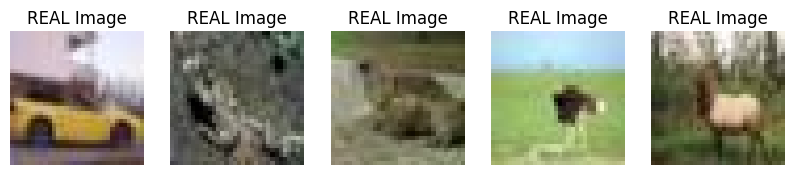

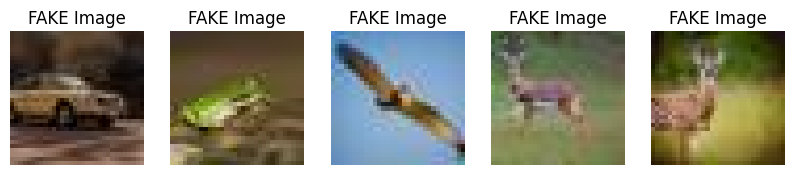

In [22]:
# Correct paths to the training and testing folders
train_dir = os.path.join(dataset_path, 'train')
test_dir = os.path.join(dataset_path, 'test')

# Function to display a grid of sample images
def visualize_sample_images(directory, class_name, num_images=5):
    class_dir = os.path.join(directory, class_name)
    image_files = os.listdir(class_dir)[:num_images]

    plt.figure(figsize=(10, 10))

    for i, image_file in enumerate(image_files):
        img_path = os.path.join(class_dir, image_file)
        img = load_img(img_path, target_size=(32, 32))
        img_array = img_to_array(img)

        plt.subplot(1, num_images, i+1)
        plt.imshow(np.uint8(img_array))
        plt.title(f'{class_name} Image')
        plt.axis('off')

    plt.show()

# Example: Visualize images from both classes (REAL and FAKE)
visualize_sample_images(train_dir, 'REAL', num_images=5)
visualize_sample_images(train_dir, 'FAKE', num_images=5)

# 3. Build the CNN model
### We'll create a simple CNN model to classify the images.

In [23]:
def build_model():
  model = models.Sequential()
  model.add(layers.Conv2D(32, (3, 3), activation='relu', input_shape=(IMG_HEIGHT, IMG_WIDTH, 3)))
  model.add(layers.MaxPooling2D((2, 2)))

  model.add(layers.Conv2D(64, (3, 3), activation='relu'))
  model.add(layers.MaxPooling2D((2, 2)))

  model.add(layers.Conv2D(128, (3, 3), activation='relu'))
  model.add(layers.MaxPooling2D((2, 2)))

  model.add(layers.Flatten())
  model.add(layers.Dense(128, activation='relu'))
  model.add(layers.Dropout(0.5))

  model.add(layers.Dense(1, activation='sigmoid'))

  model.compile(optimizer='adam',
                loss='binary_crossentropy',
                metrics=['accuracy'])

  return model

model = build_model()
model.summary()

/usr/local/lib/python3.10/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 30, 30, 32)          │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 15, 15, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 13, 13, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 6, 6, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 4, 4, 128)           │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 2, 2, 128)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 512)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │          65,664 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1)                   │             129 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 159,041 (621.25 KB)

 Trainable params: 159,041 (621.25 KB)

 Non-trainable params: 0 (0.00 B)

# 4. Train the model
### We will now train the model using the training data.

In [24]:
EPOCHS = 20

history = model.fit(
    train_generator,
    epochs=EPOCHS,
    validation_data=test_generator
)

Epoch 1/20


/usr/local/lib/python3.10/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


1563/1563 ━━━━━━━━━━━━━━━━━━━━ 129s 79ms/step - accuracy: 0.7229 - loss: 0.5414 - val_accuracy: 0.8053 - val_loss: 0.4204
Epoch 2/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 118s 75ms/step - accuracy: 0.8374 - loss: 0.3677 - val_accuracy: 0.8187 - val_loss: 0.4363
Epoch 3/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 139s 73ms/step - accuracy: 0.8577 - loss: 0.3305 - val_accuracy: 0.8425 - val_loss: 0.3705
Epoch 4/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 146s 76ms/step - accuracy: 0.8690 - loss: 0.3098 - val_accuracy: 0.8763 - val_loss: 0.2818
Epoch 5/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 120s 76ms/step - accuracy: 0.8763 - loss: 0.2934 - val_accuracy: 0.8786 - val_loss: 0.2876
Epoch 6/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 124s 79ms/step - accuracy: 0.8837 - loss: 0.2795 - val_accuracy: 0.8436 - val_loss: 0.3731
Epoch 7/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 137s 88ms/step - accuracy: 0.8870 - loss: 0.2705 - val_accuracy: 0.7987 - val_loss: 0.5383
Epoch 8/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 151s 93ms/step - accuracy: 0.8908 - lo

# 5. Evaluate the model
### After training, we can evaluate the model's performance on the test set.

In [25]:
test_loss, test_acc = model.evaluate(test_generator)
print(f'Test accuracy of Model is: {test_acc}')


313/313 ━━━━━━━━━━━━━━━━━━━━ 12s 37ms/step - accuracy: 0.8755 - loss: 0.3109
Test accuracy of Model is: 0.8736500144004822


# 6. Save the model (optional)
### You can save the model for later use.

In [26]:
model.save('real_vs_fake_image_classifier.h5')

# 7. Predict with the model
### Here’s how you can make predictions using the trained model:

In [27]:
import numpy as np
from tensorflow.keras.preprocessing import image

def predict_img(img_path, model):
    img = image.load_img(img_path, target_size=(IMG_HEIGHT, IMG_WIDTH))
    img_array = image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)
    img_array /= 255.0

    prediction = model.predict(img_array)
    if prediction[0] > 0.5:
        print("Image is Real")
    else:
        print("Image is AI Generated")

# 8. Plot training history
You can visualize the model's training performance using matplotlib.

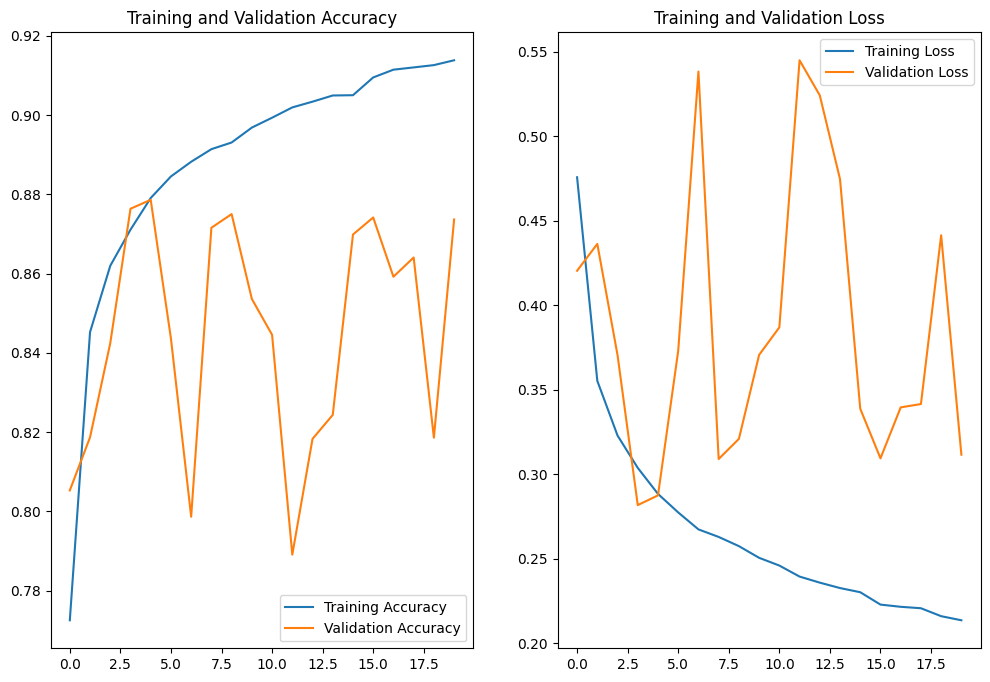

In [28]:
import matplotlib.pyplot as plt

# Plot training accuracy and loss
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

epochs_range = range(EPOCHS)

plt.figure(figsize=(12, 8))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.show()